In [1]:
import xarray as xr
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from gfatpy.lidar.preprocessing import preprocess
from gfatpy.lidar.utils.utils import signal_to_rcs
from gfatpy.utils.plot import color_list

%matplotlib inline


In [6]:
filepath =r'Z:\ICENET\backup\data\UGR\L0\2023\20230508_Granada_CHM170119_000.nc'

In [7]:
ceilo = xr.open_dataset(filepath)

(0.0, 500.0)

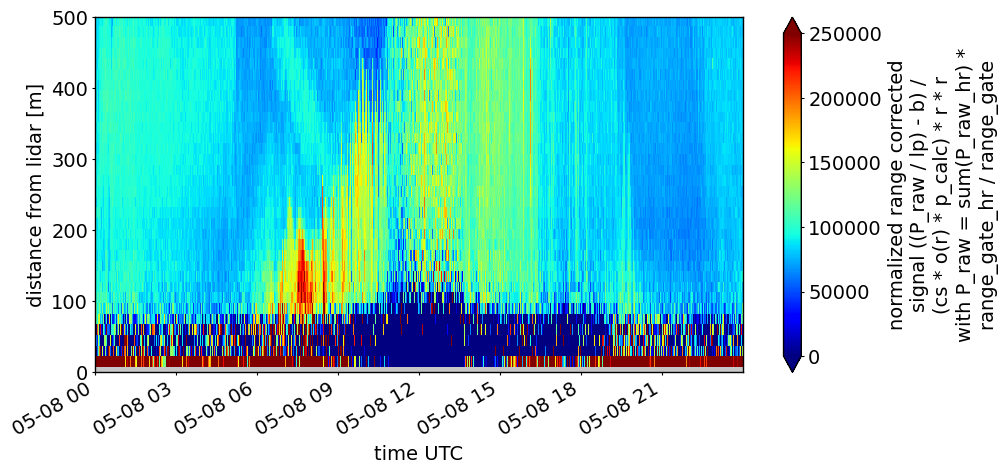

In [43]:
fig, ax = plt.subplots(figsize=[10,5])
ceilo.beta_raw.plot(y='range',vmin=0, ax=ax, vmax=2.5e5, cmap='jet')
ax.set_ylim(0,500)

(0.0, 3000.0)

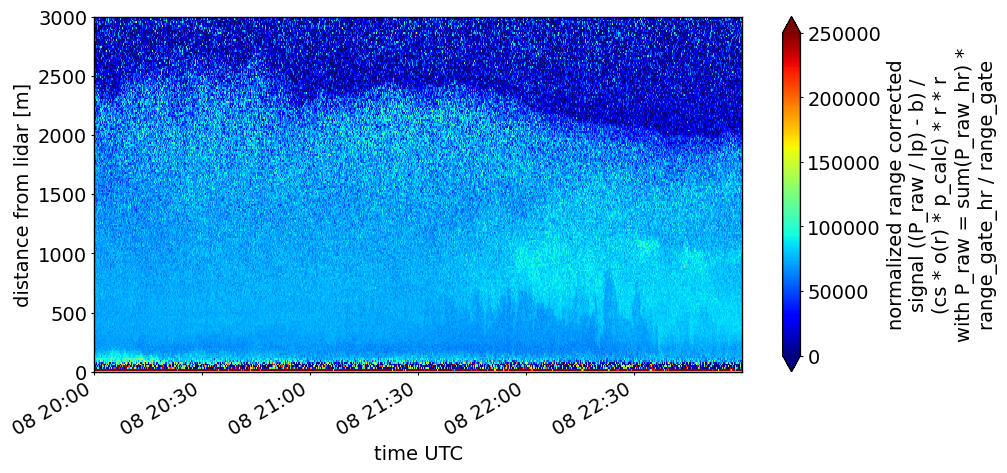

In [51]:
fig, ax = plt.subplots(figsize=[10,5])
date_str = '20230508'
hour_, hour_end = 20, 23
time_smooth = (f"{date_str}T{hour_:02}0000", f"{date_str}T{hour_end:02}0000")
ceilo.beta_raw.sel(time=slice(*time_smooth)).plot(y='range',vmin=0, ax=ax, vmax=2.5e5, cmap='jet')
ax.set_ylim(0,3000)

In [38]:
hour_ = 8
f"20230508T{hour_:02}0000"

'20230508T080000'

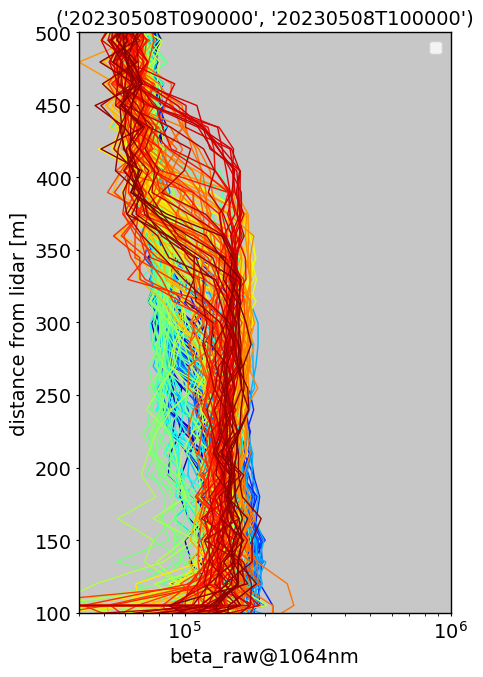

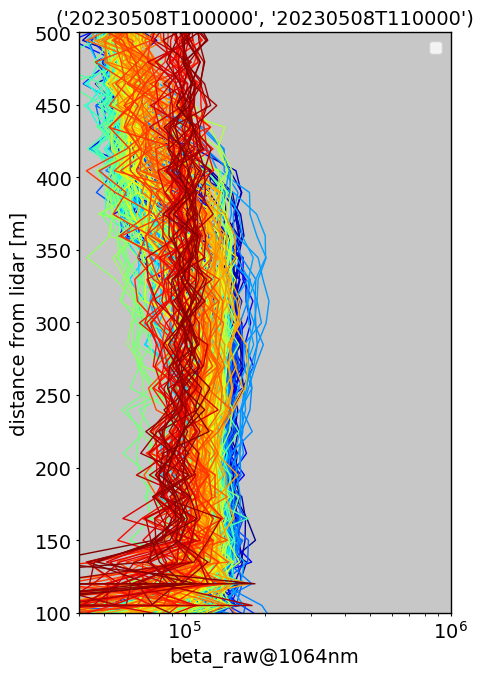

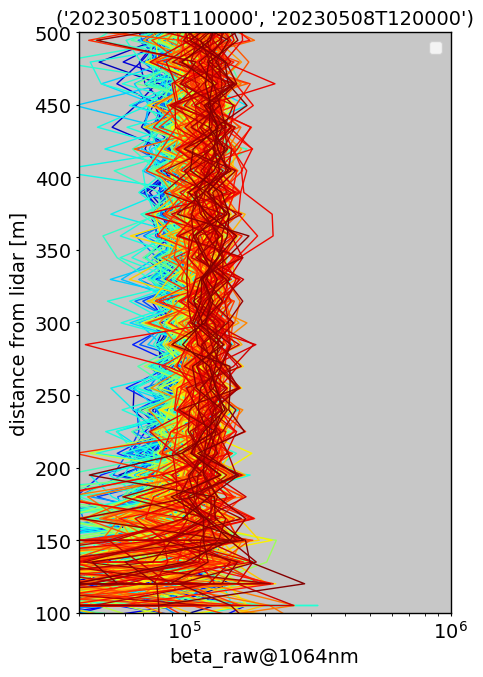

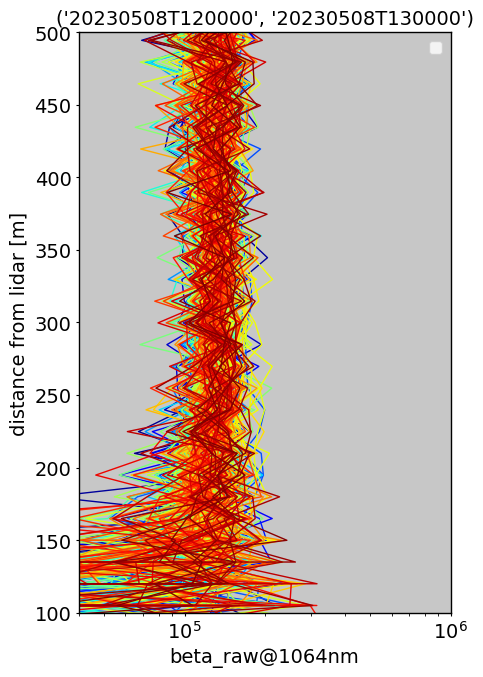

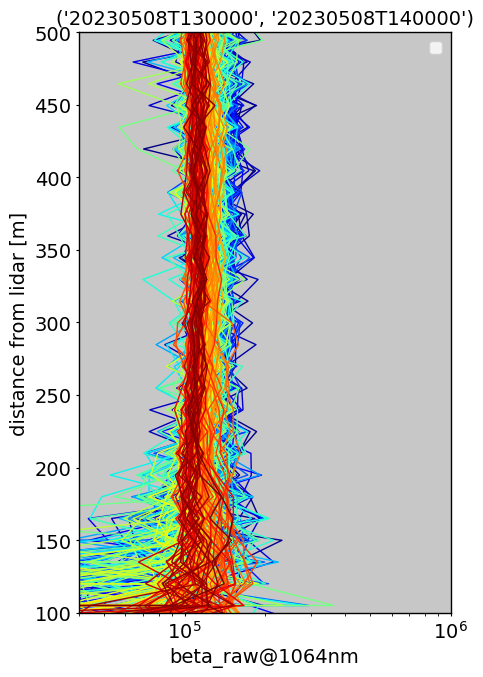

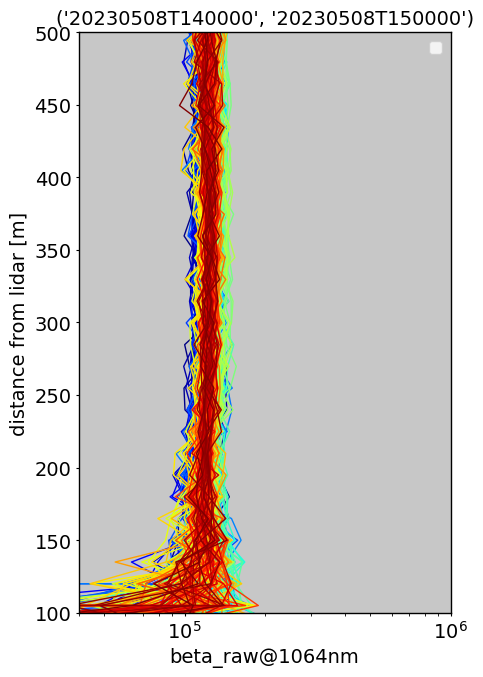

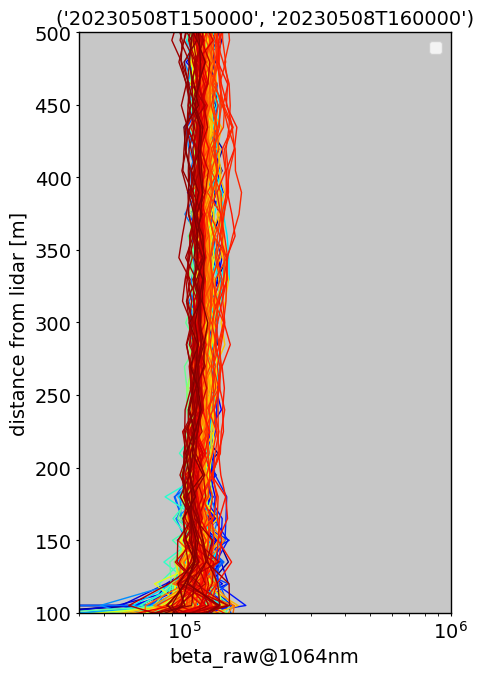

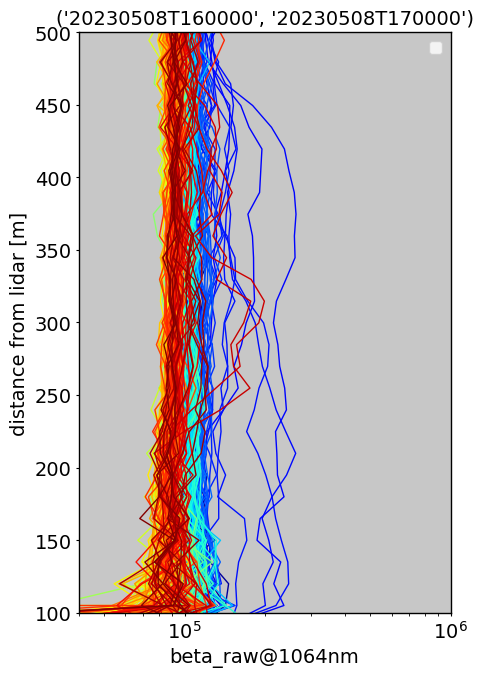

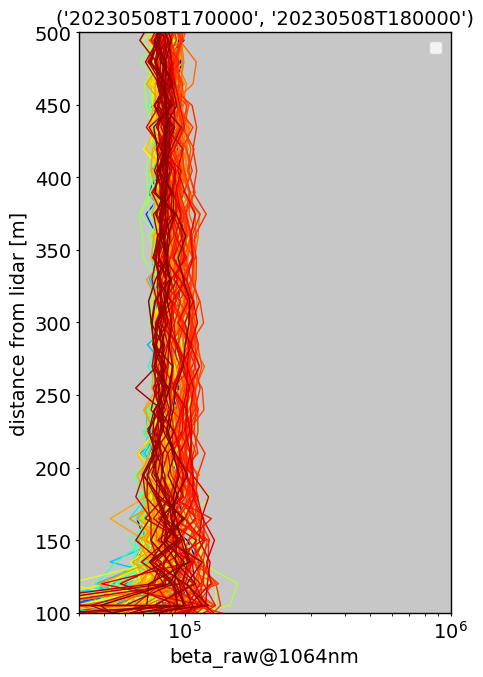

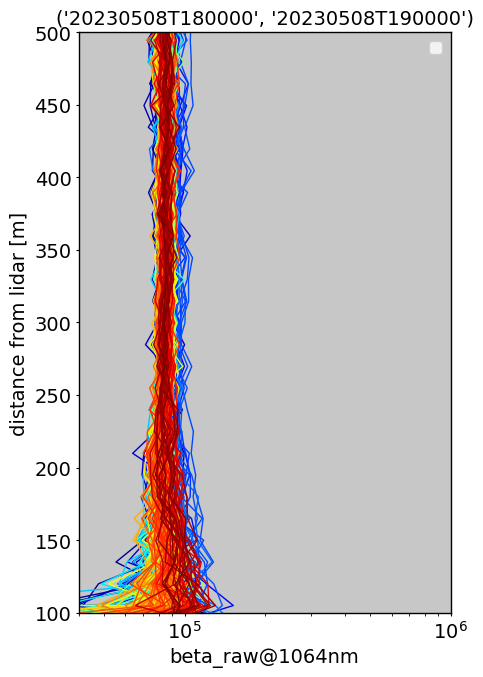

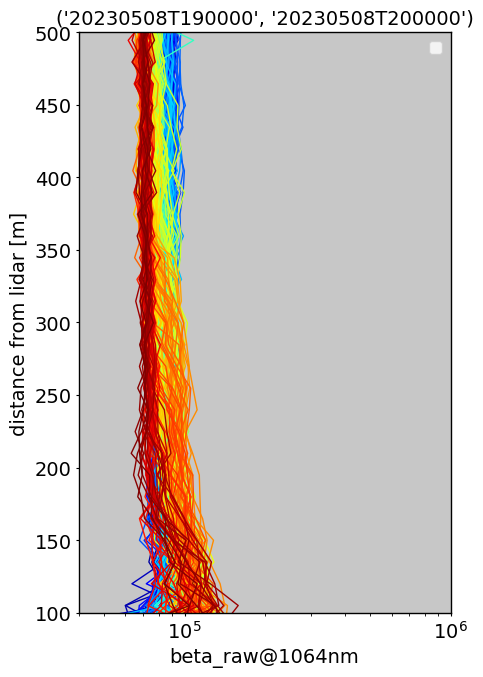

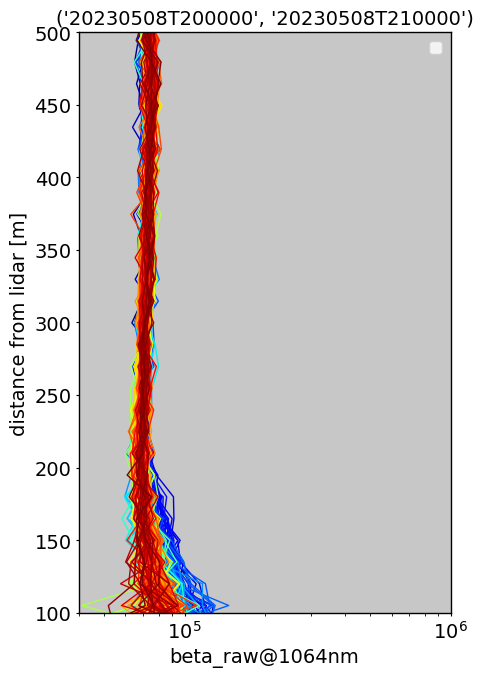

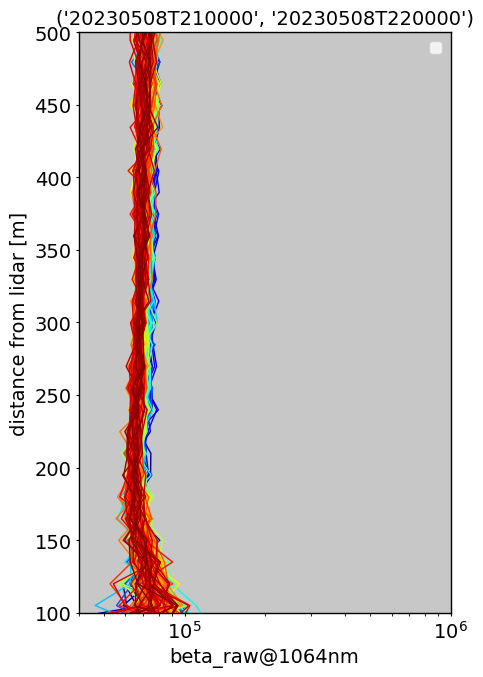

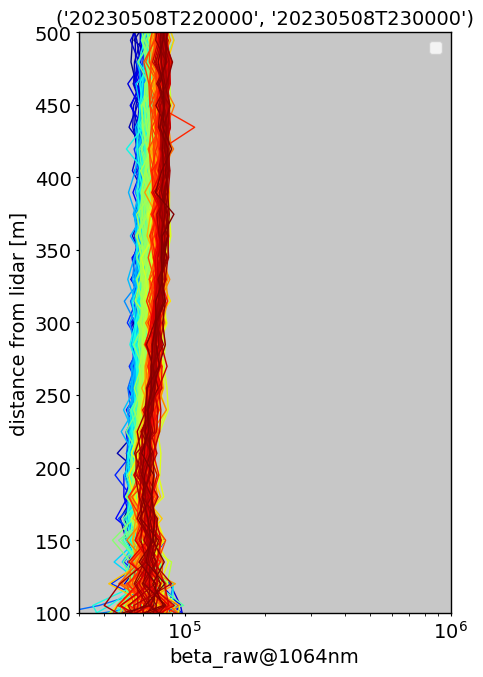

In [41]:
date_str = '20230508'
for hour_ in np.arange(9,23):
    hour_end = hour_ + 1
    time_smooth = (f"{date_str}T{hour_:02}0000", f"{date_str}T{hour_end:02}0000")
    fig, ax = plt.subplots(figsize=[5,7])
    sceilo = ceilo.beta_raw.sel(time=slice(*time_smooth))
    colors = color_list(len(sceilo.time))
    for idx, time_ in enumerate(sceilo.time):
        sceilo.sel(time=time_).plot(y='range', c=colors[idx])
    ax.set_ylim(100,500)
    ax.set_xlim(4e4,1e6)
    ax.set_xscale('log')
    ax.set_xlabel('beta_raw@1064nm')
    plt.legend([])
    ax.set_title(time_smooth)
    plt.tight_layout()
    plt.savefig(f'rcs_evolution_{date_str}_{hour_:02d}.png')


In [83]:
raw = xr.open_dataset(r"C:/Users/Usuario/Documents/gitlab/gfatpy/tests/datos/PRODUCTS/alhambra/1a/2023/05/08/alh_1a_Prs_rs_xf_20230508.nc")

In [84]:
raw.time[-1]

<xarray.DataArray 'time' ()>
array('2023-05-08T05:49:27.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 2023-05-08T05:49:27

In [2]:
lidar = preprocess(
    r"C:/Users/Usuario/Documents/gitlab/gfatpy/tests/datos/PRODUCTS/alhambra/1a/2023/05/08/alh_1a_Prs_rs_xf_20230508.nc", 
    apply_dt = True, 
    apply_bz = True, 
)

In [3]:
lidar.time[-1]

<xarray.DataArray 'time' ()>
array('2023-05-08T23:58:10.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 2023-05-08T23:58:10

Text(0.5, 1.0, "('20230508T200000', '20230508T210000')")

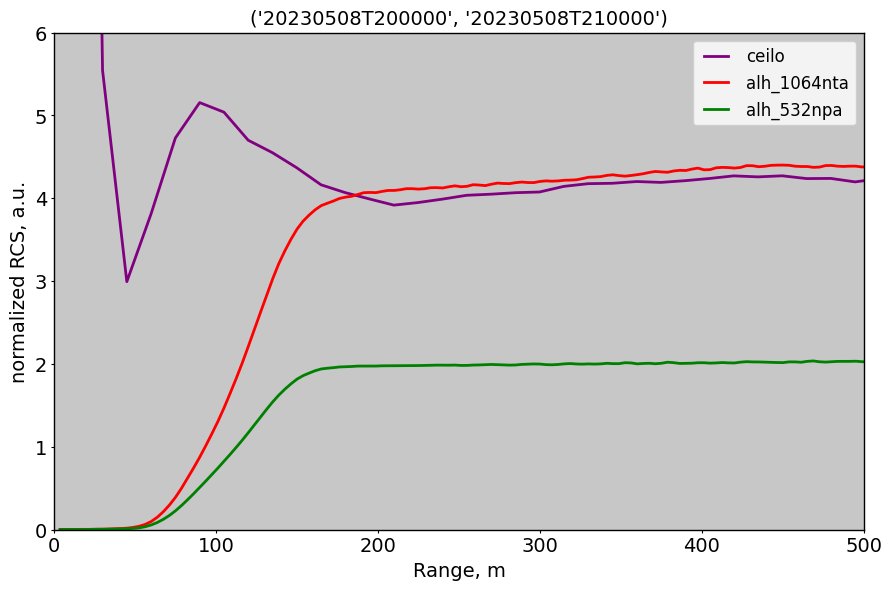

In [42]:
date_str = '20230508'
hour_, hour_end = 20, 21
time_smooth = (f"{date_str}T{hour_:02}0000", f"{date_str}T{hour_end:02}0000")
sceilo = ceilo.beta_raw.sel(time=slice(*time_smooth)).mean('time')
nsceilo = sceilo/sceilo.sel(range=slice(3000,3500)).mean('range')
slidar1064 = signal_to_rcs(lidar.signal_1064nta.sel(time=slice(*time_smooth)).mean('time'), lidar.range)
nslidar1064 = slidar1064/slidar1064.sel(range=slice(3000,3500)).mean('range')
slidar532 = signal_to_rcs(lidar.signal_532npa.sel(time=slice(*time_smooth)).mean('time'), lidar.range)
nslidar532 = slidar532/slidar532.sel(range=slice(3000,3500)).mean('range')


fig, ax = plt.subplots(figsize=[10,7])
nsceilo.plot(ax=ax, label='ceilo', c='purple', lw=2)
nslidar1064.plot(ax=ax, label='alh_1064nta', c='r', lw=2)
nslidar532.plot(ax=ax, label='alh_532npa',  c='g', lw=2)
ax.set_xlim(0,500)
ax.set_ylim(0,6)
ax.set_xlabel('Range, m')
ax.set_ylabel('normalized RCS, a.u.')
ax.legend()
ax.set_title(time_smooth)